<a href="https://colab.research.google.com/github/RajManish8340/100x-school-test/blob/main/makemore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [83]:
!wget https://raw.githubusercontent.com/karpathy/makemore/refs/heads/master/names.txt

--2026-08-15 06:33:55--  https://raw.githubusercontent.com/karpathy/makemore/refs/heads/master/names.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228145 (223K) [text/plain]
Saving to: ‘names.txt.3’

names.txt.3         100%[===================>] 222.80K  --.-KB/s    in 0.02s   

2026-08-15 06:33:55 (8.77 MB/s) - ‘names.txt.3’ saved [228145/228145]



In [84]:
with open('names.txt', 'r') as file:
  content = file.read()
names = content.splitlines()
print(names[:10])
print(names[-10:])
print("number of names:",len(names))


['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn']
['zuber', 'zubeyr', 'zyell', 'zyheem', 'zykeem', 'zylas', 'zyran', 'zyrie', 'zyron', 'zzyzx']
number of names: 32033


In [85]:
print(min(len(w) for w in names))
max((len(w) for w in names))


2


15

In [86]:
b = {}
for n in names:
  chs = ['<S>'] + list(n) + ['<E>']
  for ch1, ch2 in zip(chs, chs[1:]):
    bigram = (ch1, ch2)
    b[bigram] = b.get(bigram, 0) + 1

In [87]:
sorted(b.items(), key=lambda kv: -kv[1])

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [88]:
import torch

N = torch.zeros((27, 27), dtype=torch.int32) # chars(26) + one(.)

chars = sorted(list(set(''.join(names)))) # join joins all the names , set gives only a unique elements and make a list of it and then sort it
print(len(chars))
print(chars)

# i,s is a tuple but chars is not a tuple but the tuple comes from the enumerate function
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

print(stoi)
print(itos)


26
['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [89]:
for n in names:
  chs = ['.'] + list(n) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    N[ix1, ix2] += 1

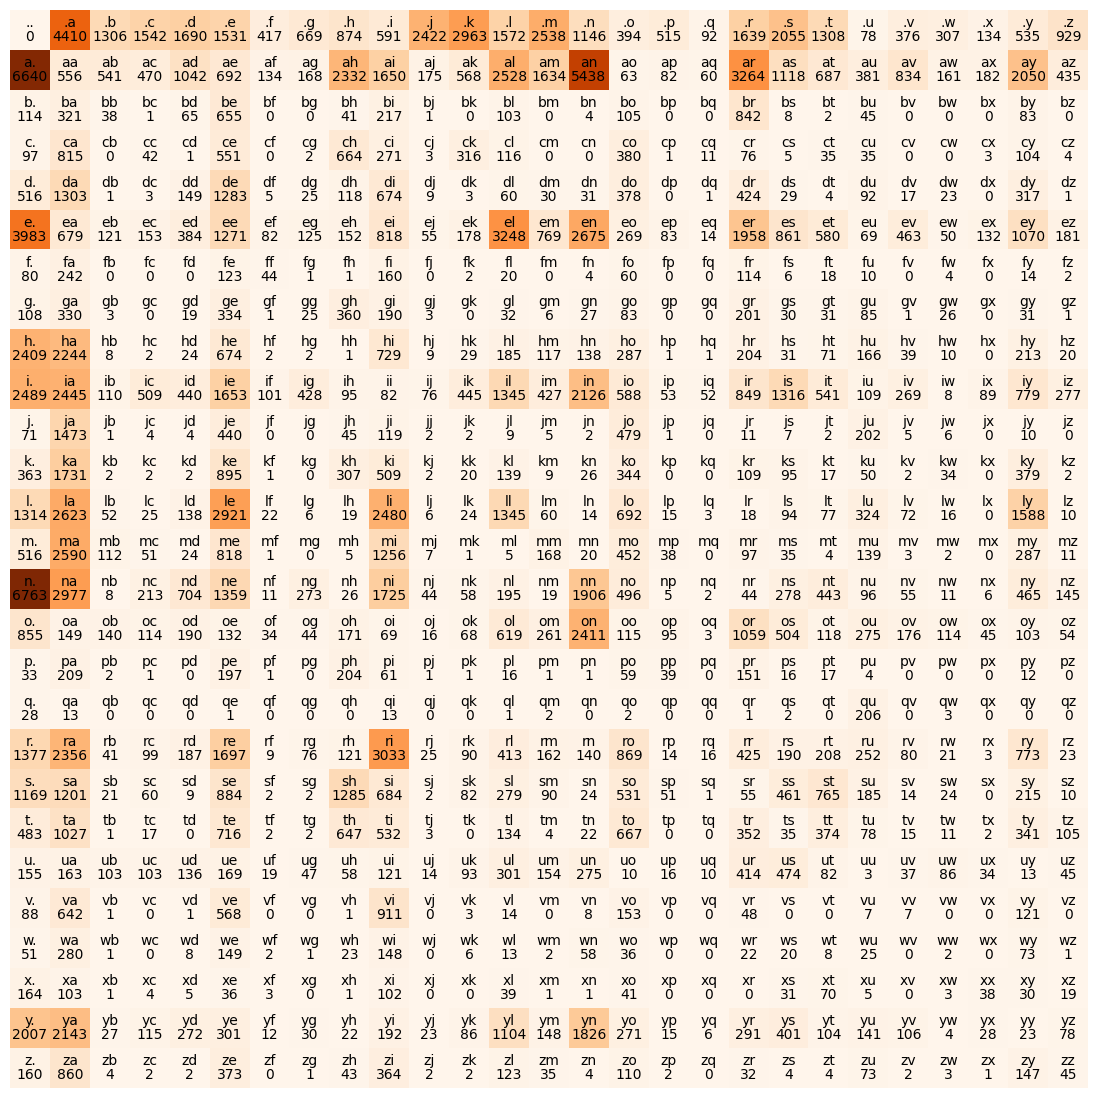

In [99]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(14,14))
plt.imshow(N, cmap='Oranges')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='black')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='black')
plt.axis('off');

In [91]:
N[0]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [92]:
p = N[0].float()
p = p/p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [93]:
g = torch.Generator().manual_seed(2147483647) # you'll get the same sequence of outputs on every rerun.

In [94]:
i = torch.multinomial(input=p, num_samples=1, replacement=True, generator=g).item()
print(i)
itos[i]

3


'c'

In [95]:
p = torch.rand(3, generator=g)
print(p)
torch.multinomial(input=p, num_samples=100, replacement=True, generator=g) # 100 samples form prob p


tensor([0.4244, 0.8139, 0.2275])


tensor([1, 0, 0, 0, 1, 1, 1, 1, 1, 2, 1, 0, 1, 2, 1, 0, 1, 2, 0, 1, 1, 1, 2, 1,
        0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1,
        0, 1, 1, 0, 0, 0, 1, 2, 0, 1, 0, 0, 0, 1, 2, 1, 0, 2, 1, 1, 1, 1, 1, 1,
        1, 2, 0, 0, 1, 2, 0, 0, 0, 1, 0, 1, 0, 2, 2, 0, 1, 1, 1, 2, 1, 0, 2, 2,
        1, 1, 0, 1])

In [96]:
# P /=P.sum(1,keepdim=True)

# 27, 27
# 27,  1    <- correct: keepdim=True, broadcasts correctly (row-wise)

# P /= P.sum(1)
# 27, 27
#  1, 27    <- wrong: without keepdim, shape becomes (27,), which broadcasts
             #  as if it were a ROW vector (1,27), aligning with COLUMNS not ROWS

In [97]:
# to smooth the probabilities such that no one is 0
P = (N+1).float()
# added accross each row(i.e. 1) which makes a comumn tensor , sum of that row will then divided by each element of the row
P /= P.sum(1,keepdim=True)
# sum of prob of each row will be 1, keep dim True for broadcasting
print(P.sum(1, keepdim=True).shape)
print(P.sum(1))
print(P.sum(1, keepdim=True))
print(P.shape)

torch.Size([27, 1])
tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])
tensor([[1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000],
        [1.0000]])
torch.Size([27, 27])


In [98]:
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
  out = []
  ix = 0
  while True:
    p = P[ix]
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))


cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
